In [1]:
%reload_ext autoreload
%autoreload 2

import os
import sys

import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

import numpy as np
from scipy import stats
import arviz as az
import healpy as hp
#import mpltern
import corner
import pickle
import logging
from tqdm import tqdm
import json

sys.path.append("../")
os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"
print(jax.devices())

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file('matplotlibrc')

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[gpu(id=0)]


## 1. Simulation

In [ ]:
save_dir = "../outputs/poisson_sim/run_230718"

In [ ]:
from models.np_model import NPModel

In [ ]:
npmodel = NPModel(
    non_poissonian=True,
    l_max=2,
    vary_gamma=True,
    bulge_hybrid=True,
    ps_cat="3fgl",
    nside=128,
)

Loading the psf correction from: /content/drive/Othercomputers/My MacBook Pro/fermi-prob-prog/notebooks/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


### 1.1 Get reasonable data values

In [3]:
s = pickle.load(open('data/posteriors/np_sviiaf_par8_samples.p', 'rb'))

In [10]:
for k in s:
    if k.startswith('Alm') or k.startswith('n') or k.startswith('sb'):
        continue
    kshow = k.ljust(15)[:14]
    print(f'{kshow} : {np.median(s[k]):.3f}, {np.quantile(s[k], 0.18):.3f} - {np.quantile(s[k], 0.82):.3f}')

C              : 2.538, 2.015 - 3.195
S_bub          : 1.315, 1.232 - 1.396
S_dif          : 11.147, 10.992 - 11.279
S_gce          : 0.386, 0.288 - 0.516
S_ics          : 5.925, 5.775 - 6.086
S_iso          : 0.536, 0.423 - 0.680
S_psc          : 2.869, 1.558 - 3.996
Sps_dsk        : 1.015, 0.936 - 1.096
Sps_gce        : 1.086, 0.977 - 1.180
f_bulge_poiss  : 0.253, 0.173 - 0.357
f_bulge_ps     : 0.294, 0.216 - 0.387
gamma_poiss    : 0.924, 0.756 - 1.111
gamma_ps       : 1.211, 1.115 - 1.304
lambdas_dsk    : 0.414, 0.281 - 0.567
lambdas_gce    : 0.376, 0.254 - 0.518
theta_p_mcderm : 0.101, 0.015 - 0.452
theta_p_mcderm : 0.075, 0.010 - 0.357
theta_p_mcderm : 0.044, 0.009 - 0.160
theta_p_macias : 0.045, 0.000 - 0.483
theta_p_colema : 0.237, 0.008 - 0.659
theta_ps_mcder : 0.040, 0.008 - 0.176
theta_ps_mcder : 0.003, 0.000 - 0.068
theta_ps_mcder : 0.031, 0.006 - 0.135
theta_ps_macia : 0.611, 0.083 - 0.893
theta_ps_colem : 0.034, 0.000 - 0.572
theta_MO_ics   : 0.951, 0.883 - 0.980
theta_MA_

In [ ]:
var_dict = dict(
    theta_pib = np.array([1., 0., 0.]), # O A F
    theta_ics = np.array([1., 0., 0.]),
    S_iso = 0.3, S_bub = 0.2, S_psc = 0.5, S_pib = 10., S_ics = 6.,
    S_dsk = 1.2, zs = 0.5, C = 2.5,
    S_gce = 1., gamma_poiss = 1.2, f_bulge_poiss = 0.3,
    theta_bulge_poiss = np.array([1., 0., 0., 0., 0.]),
)
mu = npmodel.simulate_mu(var_dict)
#var_dict['mu'] = np.array(mu)
with open(f"{save_dir}/truth.json", 'w') as jf:
    save_dict = {}
    for k, item in var_dict.items():
        if isinstance(item, np.ndarray):
            save_dict[k] = item.tolist()
        else:
            save_dict[k] = item
    json.dump(save_dict, jf)
np.save(f"{save_dir}/mu.npy", mu)

In [ ]:
rng_key = jax.random.PRNGKey(42)

for i in tqdm(range(100)):
    rng_key, key = jax.random.split(rng_key)
    counts = jax.random.poisson(key, mu)
    np.save(f"{save_dir}/counts_{i}.npy", np.array(counts, dtype=np.int32))

100%|██████████| 100/100 [00:01<00:00, 70.69it/s]


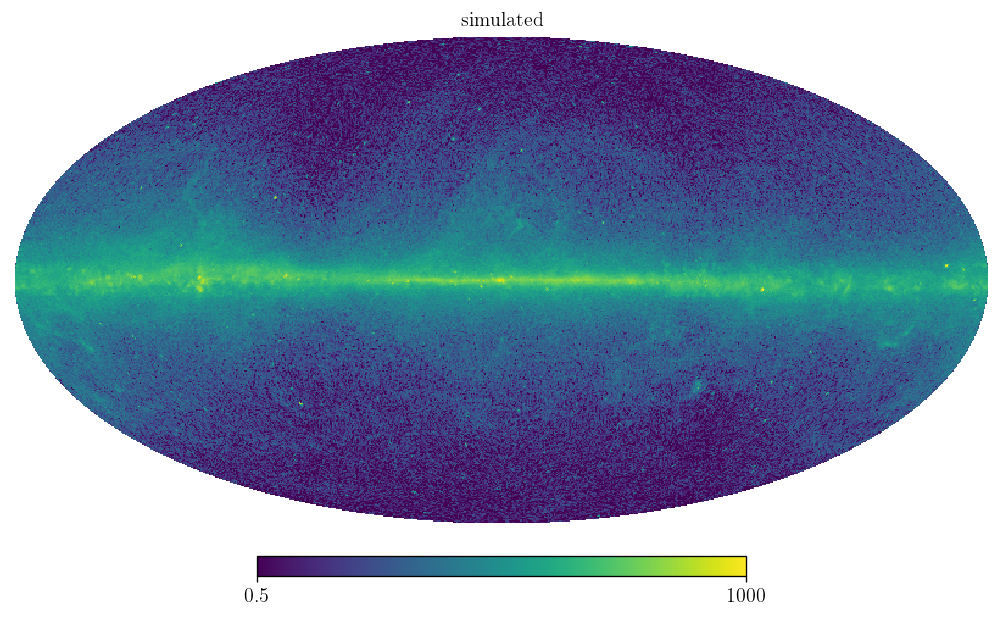

In [ ]:
hp.mollview(jnp.clip(counts, 0.5, None), norm='log', max=1000, title='simulated')
plt.show()

## 2. Fit

### 2.1 SVI

In [ ]:
for i in range(74,80):
    counts = jnp.array(np.load(f"{save_dir}/counts_{i}.npy"), dtype=jnp.int32)
    svi_results = npmodel.fit_svi(
        rng_key=jax.random.PRNGKey(4234),
        n_steps=2000,
        guide="iaf",
        lr=5e-5,
        num_particles=8,
        data=jnp.array(counts),
    )
    pickle.dump(svi_results, open(f"{save_dir}/svi_results_{i}.p", 'wb'))
    samples = npmodel.get_svi_samples(
        rng_key=jax.random.PRNGKey(42),
        num_samples=50000,
    )
    pickle.dump(samples, open(f"{save_dir}/samples_{i}.p", 'wb'))

In [ ]:
plt.plot(svi_results.losses)
plt.loglog()

## 3. View

In [ ]:
from utils.multi_corner import multi_corner

In [ ]:
samples = pickle.load(open('../outputs/poisson_sim/test_samples.p', 'rb'))

In [ ]:
samples_dict = {
    '' : samples
}
colors_dict = {
    '' : 'k'
}
labels_dict = {
    '' : 'test'
}
plot_var_names = [
    'S_bub', 'S_ics', 'S_iso', 'S_dif',
    'C', 'zs',
    'S_gce', 'gamma_poiss', 'f_bulge_poiss',
    'theta_pib_ModelO', 'theta_p_mcdermott2022'
]

logging.getLogger().setLevel(logging.ERROR)
multi_corner(
    samples_dict, plot_var_names,
    colors_dict=colors_dict, labels_dict=labels_dict,
    hist_bin_factor=1, save_fn='../outputs/test.pdf'
)

## 4. Coverage test

In [3]:
def find_hdi_prob(samples, value, low, high, level=15):
    """Recursively find probability for which the hdi have value on boundary."""
    mid = (low + high) / 2
    if level == 0:
        return mid
    hdi = az.hdi(samples, mid)
    if hdi[0] <= value and value <= hdi[1]:
        return find_hdi_prob(samples, value, low, mid, level-1)
    else:
        return find_hdi_prob(samples, value, mid, high, level-1)

In [5]:
k = 'S_gce'
run_dir = "../outputs/poisson_sim/run_230718"

In [6]:
truth_dict = json.load(open(f"{run_dir}/truth.json", 'r'))
true_val = truth_dict[k]
print(k, true_val)

S_gce 1.0


In [19]:
arr = []
sample_fns = [fn for fn in os.listdir(run_dir) if fn.startswith('sample')]
for fn in tqdm(sample_fns):
    #sk = k if k != 'S_pib' else 'S_dif'
    s = pickle.load(open(f"{run_dir}/{fn}", 'rb'))
    arr.append(np.array(s['S_gce']))

100%|█████████████████████████████████████████████████████████████████████████████| 100/100 [00:02<00:00, 45.96it/s]


In [20]:
np.mean(arr)

1.0879186

In [22]:
sample_fns = [fn for fn in os.listdir(run_dir) if fn.startswith('sample')]
ps = []
for fn in tqdm(sample_fns):
    #sk = k if k != 'S_pib' else 'S_dif'
    s = pickle.load(open(f"{run_dir}/{fn}", 'rb'))
    samples = np.array(s['S_gce'])
    p = find_hdi_prob(samples, 1.0879186, 0, 1, level=15)
    ps.append(p)
ps.sort()

100%|█████████████████████████████████████████████████████████████████████████████| 100/100 [00:02<00:00, 46.17it/s]


In [21]:
sample_fns = [fn for fn in os.listdir(run_dir) if fn.startswith('sample')]
ps_SSps = []
for fn in tqdm(sample_fns):
    #sk = k if k != 'S_pib' else 'S_dif'
    s = pickle.load(open(f"{run_dir}/{fn}", 'rb'))
    samples = np.array(s['S_gce']) + np.array(s['Sps_gce'])
    p = find_hdi_prob(samples, 1.0879186, 0, 1, level=15)
    ps_SSps.append(p)
ps_SSps.sort()

100%|█████████████████████████████████████████████████████████████████████████████| 100/100 [00:02<00:00, 45.76it/s]


In [8]:
n_sample = 50000
ps_mock = []
for _ in tqdm(range(100)):
    true_val_mock = 0
    measured = np.random.normal(true_val_mock, 1)
    samples = np.random.normal(measured, 1, n_sample)
    p = find_hdi_prob(samples, true_val_mock, 0, 1, level=15)
    ps_mock.append(p)
ps_mock.sort()

100%|████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 128.69it/s]


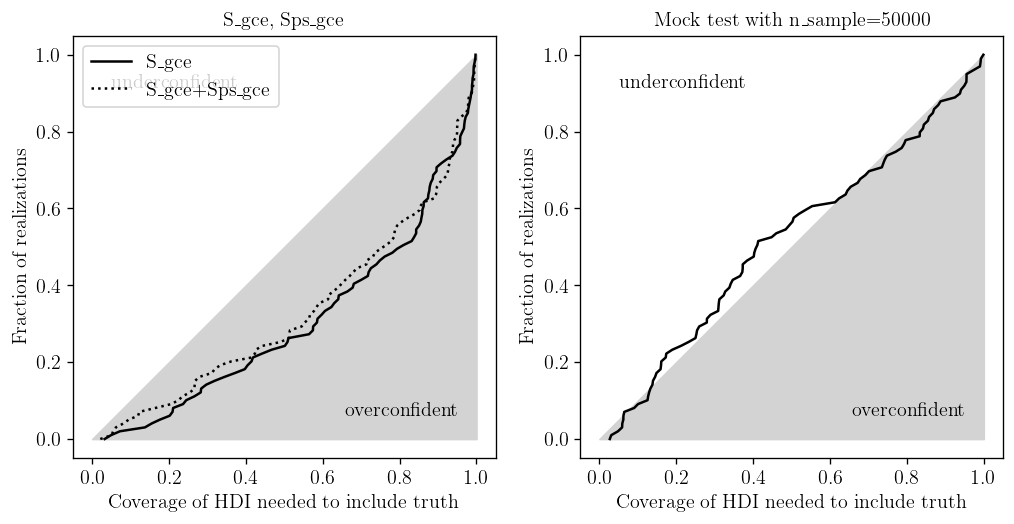

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].fill_between([0,1], [0,1], color='lightgray')
axs[0].plot(ps, np.linspace(0, 1, len(ps)), color='k', label='S_gce')
axs[0].plot(ps_SSps, np.linspace(0, 1, len(ps_SSps)), color='k', ls=':', label='S_gce+Sps_gce')
axs[0].set(aspect=1)
axs[0].set(xlabel='Coverage of HDI needed to include truth', ylabel='Fraction of realizations',
           title='S_gce, Sps_gce');
axs[0].text(0.95, 0.05, 'overconfident', ha='right', va='bottom')
axs[0].text(0.05, 0.95, 'underconfident', ha='left', va='top')
axs[0].legend()

axs[1].fill_between([0,1], [0,1], color='lightgray')
axs[1].plot(ps_mock, np.linspace(0, 1, len(ps_mock)), color='k')
axs[1].set(aspect=1)
axs[1].set(xlabel='Coverage of HDI needed to include truth', ylabel='Fraction of realizations',
        title='Mock test with n_sample=50000');
axs[1].text(0.95, 0.05, 'overconfident', ha='right', va='bottom')
axs[1].text(0.05, 0.95, 'underconfident', ha='left', va='top')
fig.savefig('plots/ROC/S_gce_Sps_gce_ROC.pdf');

100%|█████████████████████████████████████████████████████████████████████████████| 100/100 [02:36<00:00,  1.56s/it]


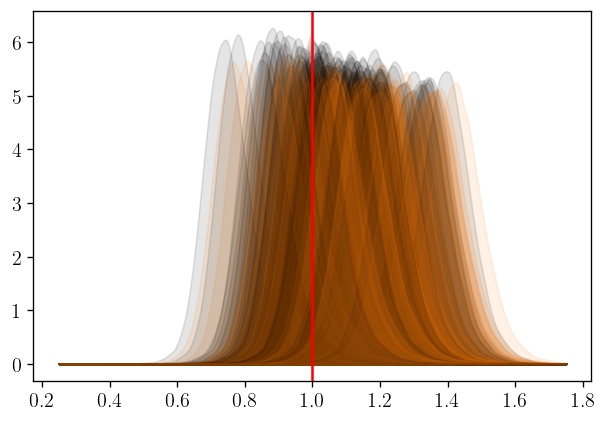

In [18]:
fig, ax = plt.subplots()

sample_fns = [fn for fn in os.listdir(run_dir) if fn.startswith('sample')]

for fn in tqdm(sample_fns):
    #sk = k if k != 'S_pib' else 'S_dif'
    s = pickle.load(open(f"{run_dir}/{fn}", 'rb'))
    samples = np.array(s['S_gce'])
    kde = stats.gaussian_kde(samples)
    val_s = np.linspace(0.25, 1.75, 1000)
    ax.fill_between(val_s, kde(val_s), color='k', alpha=0.1)
    samples = np.array(s['S_gce']) + np.array(s['Sps_gce'])
    kde = stats.gaussian_kde(samples)
    val_s = np.linspace(0.25, 1.75, 1000)
    ax.fill_between(val_s, kde(val_s), color='C1', alpha=0.1)
ax.axvline(true_val, color='red')

In [18]:
sample_fns = [fn for fn in os.listdir(run_dir) if fn.startswith('sample')]
std_s = []
for fn in tqdm(sample_fns):
    sk = k if k != 'S_pib' else 'S_dif'
    s = pickle.load(open(f"{run_dir}/{fn}", 'rb'))
    samples = np.array(s[sk])
    std_s.append(np.std(samples))
print(np.mean(std_s))

100%|█████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 61.43it/s]

0.07844684


in comparison, a mock test

100%|█████████████████████████████████████████████████████████████████████████████| 100/100 [01:05<00:00,  1.54it/s]


TypeError: 'Text' object is not callable

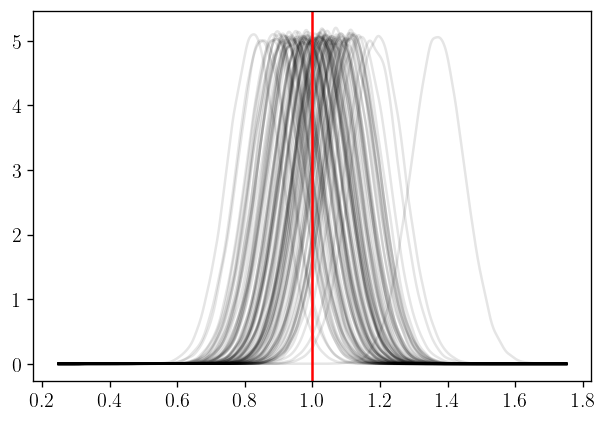

In [19]:
fig, ax = plt.subplots()

for _ in tqdm(range(100)):
    truth = 1
    std = 0.07844684
    measured = np.random.normal(truth, std)
    samples = np.random.normal(measured, std, 50000)
    kde = stats.gaussian_kde(samples)
    val_s = np.linspace(0.25, 1.75, 1000)
    ax.plot(val_s, kde(val_s), color='k', alpha=0.1)
ax.axvline(true_val, color='red')
ax.set(title='mock')

## Get uncertainty band for 100 samples

In [ ]:
n_r = 100
ps_mock_arr = []
for _ in tqdm(range(1000)):
    ps_mock = []
    for _ in range(n_r):
        true_val_mock = 0
        measured = np.random.normal(true_val_mock, 1)
        samples = np.random.normal(measured, 1, 50000)
        p = find_hdi_prob(samples, true_val_mock, 0, 1, level=15)
        ps_mock.append(p)
    ps_mock.sort()
    ps_mock_arr.append(ps_mock)

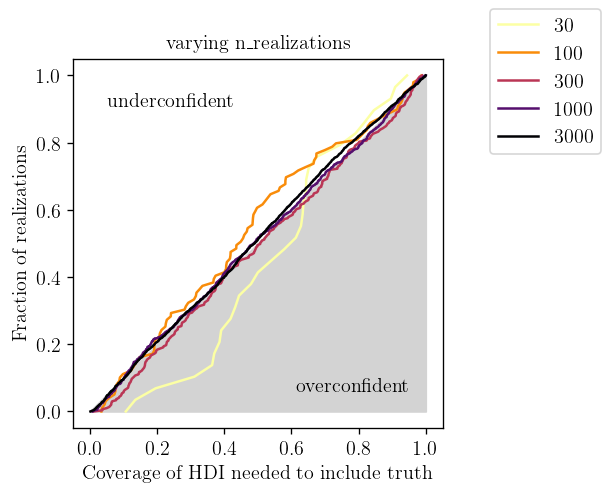

In [66]:
fig, ax = plt.subplots()

ax.fill_between([0,1], [0,1], color='lightgray')
for i in range(5):
    color = cms['inferno_r'](i/4.)
    ax.plot(ps_mock_arr[i], np.linspace(0, 1, len(ps_mock_arr[i])), color=color, label=str(n_r_arr[i]))
ax.set(aspect=1)
ax.set(xlabel='Coverage of HDI needed to include truth', ylabel='Fraction of realizations', title='varying n_realizations');
ax.text(0.95, 0.05, 'overconfident', ha='right', va='bottom')
ax.text(0.05, 0.95, 'underconfident', ha='left', va='top')
fig.legend()

## Mock tests

In [55]:
n_sample_arr = [10000, 30000, 100000, 300000, 1000000]
ps_mock_arr = []
for n_sample in n_sample_arr:
    ps_mock = []
    for _ in tqdm(range(100)):
        true_val_mock = 0
        measured = np.random.normal(true_val_mock, 1)
        samples = np.random.normal(measured, 1, n_sample)
        p = find_hdi_prob(samples, true_val_mock, 0, 1, level=15)
        ps_mock.append(p)
    ps_mock.sort()
    ps_mock_arr.append(ps_mock)

100%|█████████████████████████████████████████████████████████████████████████████| 100/100 [00:26<00:00,  3.75it/s]


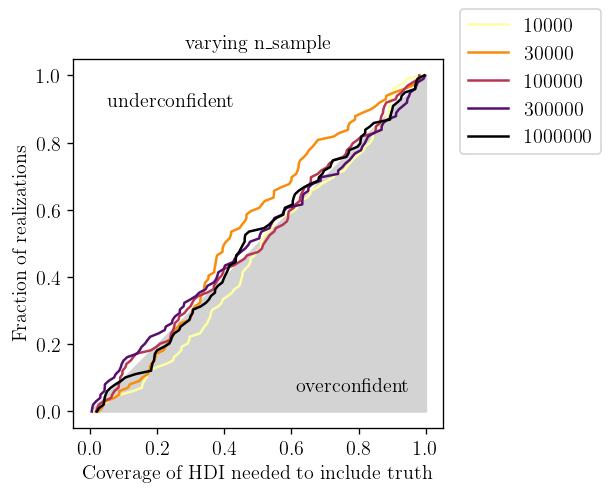

In [63]:
fig, ax = plt.subplots()

ax.fill_between([0,1], [0,1], color='lightgray')
for i in range(5):
    color = cms['inferno_r'](i/4.)
    ax.plot(ps_mock_arr[i], np.linspace(0, 1, len(ps_mock_arr[i])), color=color, label=str(n_sample_arr[i]))
ax.set(aspect=1)
ax.set(xlabel='Coverage of HDI needed to include truth', ylabel='Fraction of realizations', title='varying n_sample');
ax.text(0.95, 0.05, 'overconfident', ha='right', va='bottom')
ax.text(0.05, 0.95, 'underconfident', ha='left', va='top')
fig.legend()

In [65]:
n_r_arr = [30, 100, 300, 1000, 3000]
ps_mock_arr = []
for n_r in n_r_arr:
    ps_mock = []
    for _ in tqdm(range(n_r)):
        true_val_mock = 0
        measured = np.random.normal(true_val_mock, 1)
        samples = np.random.normal(measured, 1, 50000)
        p = find_hdi_prob(samples, true_val_mock, 0, 1, level=15)
        ps_mock.append(p)
    ps_mock.sort()
    ps_mock_arr.append(ps_mock)

100%|██████████████████████████████████████████████████████████████████████████| 3000/3000 [00:21<00:00, 140.86it/s]


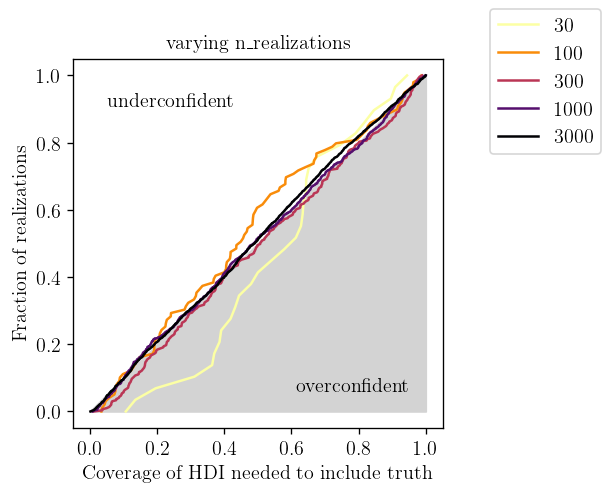

In [66]:
fig, ax = plt.subplots()

ax.fill_between([0,1], [0,1], color='lightgray')
for i in range(5):
    color = cms['inferno_r'](i/4.)
    ax.plot(ps_mock_arr[i], np.linspace(0, 1, len(ps_mock_arr[i])), color=color, label=str(n_r_arr[i]))
ax.set(aspect=1)
ax.set(xlabel='Coverage of HDI needed to include truth', ylabel='Fraction of realizations', title='varying n_realizations');
ax.text(0.95, 0.05, 'overconfident', ha='right', va='bottom')
ax.text(0.05, 0.95, 'underconfident', ha='left', va='top')
fig.legend()